# TDA Cache vs SSM Benchmark Analysis

In [1]:
# Install required libraries if missing in the environment
%pip install -q pandas matplotlib seaborn


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: /opt/homebrew/opt/python@3.11/bin/python3.11 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style for publication-ready graphs
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 12})

# UCF101 Benchmark Performance

In [ ]:
DATASET_NAME = 'ucf101'  
RESULTS_DIR = f'results/{DATASET_NAME}_benchmark'

summary_path = os.path.join(RESULTS_DIR, 'summary.csv')
curves_path = os.path.join(RESULTS_DIR, 'curves.csv')

if not os.path.exists(summary_path):
    raise FileNotFoundError(f"Could not find results for {DATASET_NAME} at {summary_path}")

print(f"Loading results from: {RESULTS_DIR}")
summary_df = pd.read_csv(summary_path)
curves_df = pd.read_csv(curves_path)

display(summary_df.head())

Loading results from: results/ucf101_benchmark


,dataset,method,stream_length,cache_size,accuracy,final_forgetting,mean_forgetting,avg_step_time_ms,total_runtime_s,peak_device_memory_mb,adapter_memory_mb,num_samples
0,ucf101,tda_cache_k1,100,1,68.0,32.0,23.853289,22.685311,50.998572,420.790771,0.064812,100
1,ucf101,tda_cache_k5,100,5,69.0,31.0,19.305088,24.634374,51.131267,435.853027,0.204174,100
2,ucf101,tda_cache_k10,100,10,75.0,25.0,14.391831,25.162823,50.687945,457.911621,0.343151,100
3,ucf101,tda_cache_k20,100,20,79.0,21.0,12.410655,24.749768,51.137940,484.040527,0.525482,100
4,ucf101,tda_ssm,100,-1,73.0,27.0,19.047475,25.406058,51.087917,414.576904,0.828169,100


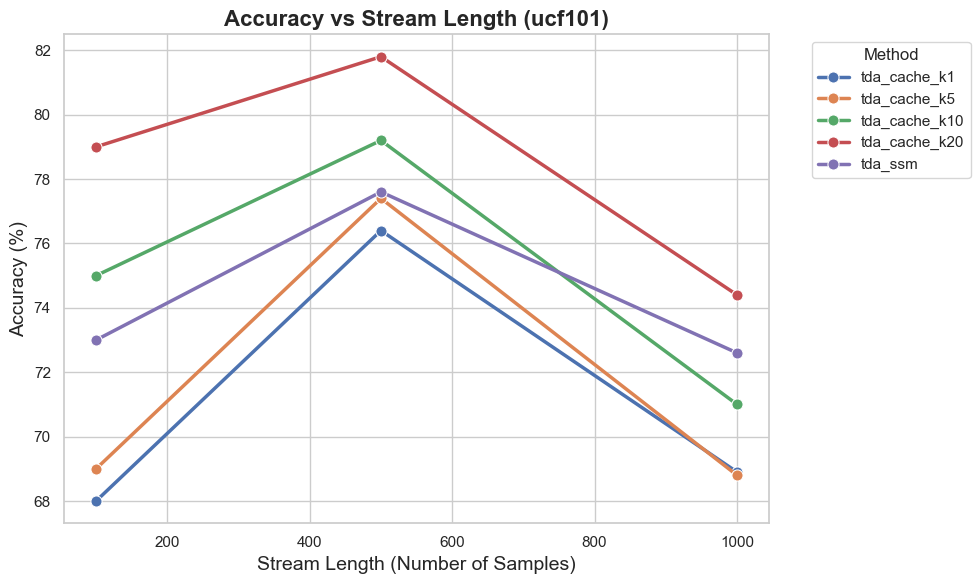

In [16]:
plt.figure(figsize=(10, 6))
sns.lineplot(data=summary_df, x='stream_length', y='accuracy', hue='method', marker='o', linewidth=2.5, markersize=8)
plt.title(f'Accuracy vs Stream Length ({DATASET_NAME})', fontsize=16, fontweight='bold')
plt.xlabel('Stream Length (Number of Samples)', fontsize=14)
plt.ylabel('Accuracy (%)', fontsize=14)
plt.legend(title='Method', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

How much does the model "forget" past classes as it adapts to new ones?
Tracking the forgetting metric over time. 

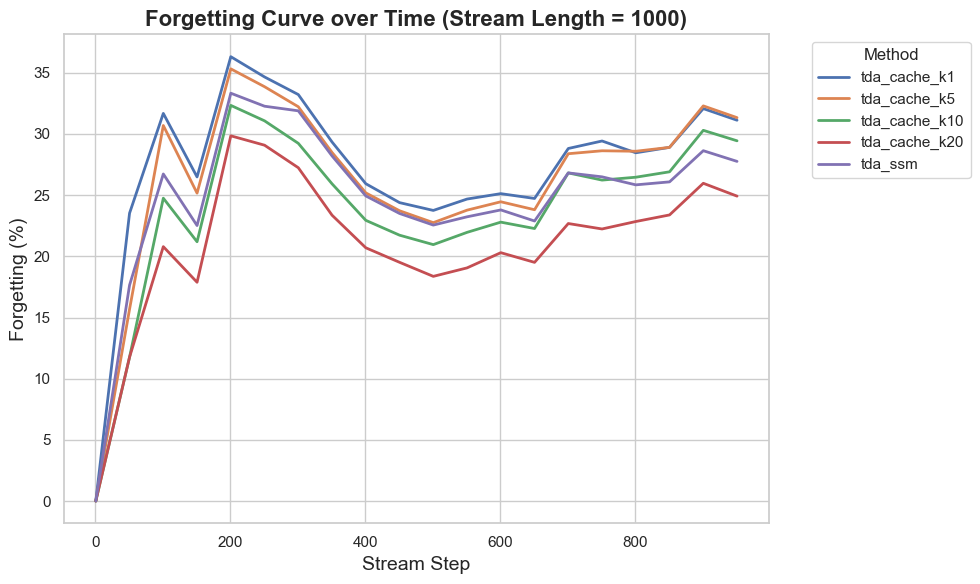

In [17]:
# Plot forgetting curve for the longest stream length available
max_stream = curves_df['stream_length'].max()
subset_curves = curves_df[curves_df['stream_length'] == max_stream]

plt.figure(figsize=(10, 6))
sns.lineplot(data=subset_curves, x='step', y='forgetting', hue='method', linewidth=2)
plt.title(f'Forgetting Curve over Time (Stream Length = {max_stream})', fontsize=16, fontweight='bold')
plt.xlabel('Stream Step', fontsize=14)
plt.ylabel('Forgetting (%)', fontsize=14)
plt.legend(title='Method', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

/var/folders/xx/t73hkxhx7xj95d9rl4spgtb00000gn/T/ipykernel_43901/3518068921.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=max_stream_summary, x='method', y='adapter_memory_mb', ax=axes[0], palette='viridis')
/var/folders/xx/t73hkxhx7xj95d9rl4spgtb00000gn/T/ipykernel_43901/3518068921.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=max_stream_summary, x='method', y='avg_step_time_ms', ax=axes[1], palette='magma')


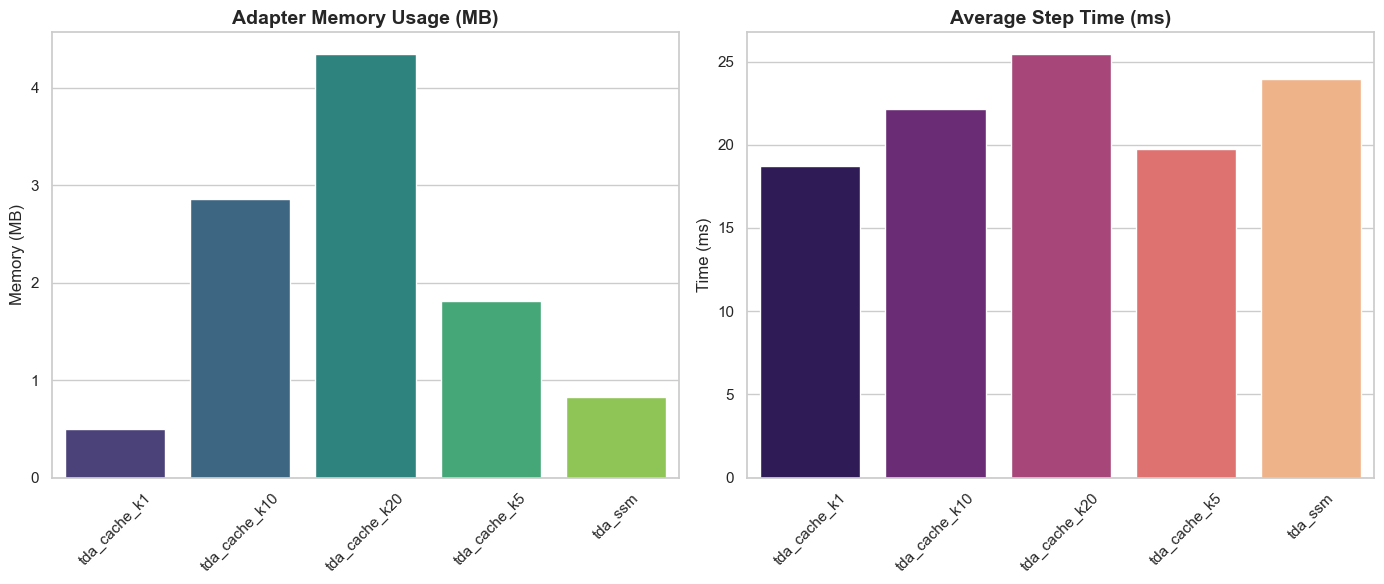

In [18]:
# Filter for the maximum stream length to compare efficiency
max_stream_summary = summary_df[summary_df['stream_length'] == summary_df['stream_length'].max()].copy()
max_stream_summary.sort_values('method', inplace=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Memory Plot
sns.barplot(data=max_stream_summary, x='method', y='adapter_memory_mb', ax=axes[0], palette='viridis')
axes[0].set_title('Adapter Memory Usage (MB)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Memory (MB)', fontsize=12)
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=45)

# Runtime Plot
sns.barplot(data=max_stream_summary, x='method', y='avg_step_time_ms', ax=axes[1], palette='magma')
axes[1].set_title('Average Step Time (ms)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Time (ms)', fontsize=12)
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Oxford Pets Benchmark Performance


In [ ]:
DATASET_NAME = 'oxford_pets'  
RESULTS_DIR = f'results/{DATASET_NAME}_benchmark'

summary_path = os.path.join(RESULTS_DIR, 'summary.csv')
curves_path = os.path.join(RESULTS_DIR, 'curves.csv')

if not os.path.exists(summary_path):
    raise FileNotFoundError(f"Could not find results for {DATASET_NAME} at {summary_path}")

print(f"Loading results from: {RESULTS_DIR}")
summary_df = pd.read_csv(summary_path)
curves_df = pd.read_csv(curves_path)

display(summary_df.head())

Loading results from: results/oxford_pets_benchmark


,dataset,method,stream_length,cache_size,accuracy,final_forgetting,mean_forgetting,avg_step_time_ms,total_runtime_s,peak_device_memory_mb,adapter_memory_mb,num_samples
0,oxford_pets,tda_cache_k1,100,1,79.0,21.0,23.941995,23.095974,51.077464,420.792725,0.083302,100
1,oxford_pets,tda_cache_k5,100,5,81.0,19.0,23.490159,21.043759,51.111277,429.824951,0.162697,100
2,oxford_pets,tda_cache_k10,100,10,88.0,12.0,15.540868,21.846662,50.707571,437.599121,0.206371,100
3,oxford_pets,tda_cache_k20,100,20,95.0,5.0,10.662313,23.176432,51.451603,458.841309,0.285908,100
4,oxford_pets,tda_ssm,100,-1,81.0,19.0,22.863544,26.929275,51.127198,415.169678,0.294355,100


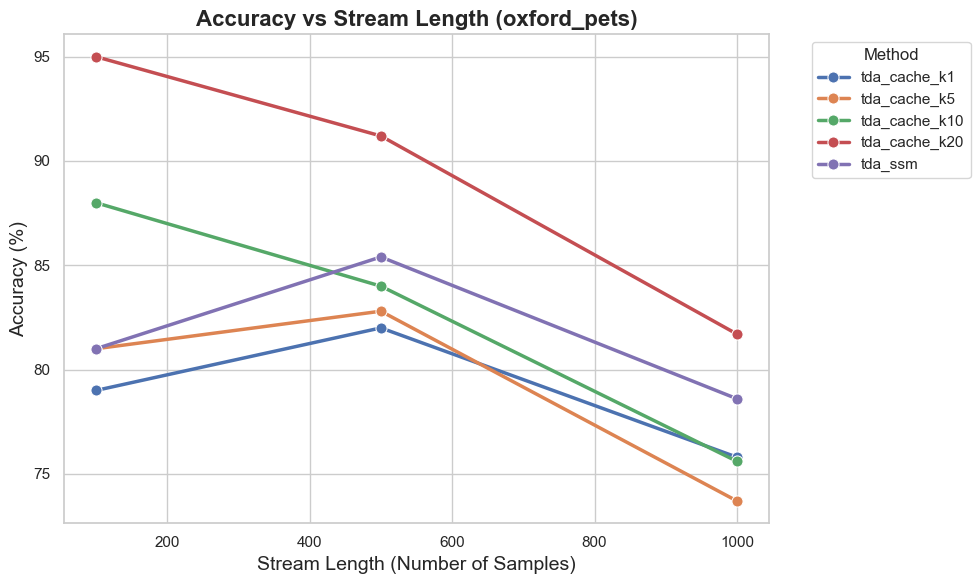

In [20]:
plt.figure(figsize=(10, 6))
sns.lineplot(data=summary_df, x='stream_length', y='accuracy', hue='method', marker='o', linewidth=2.5, markersize=8)
plt.title(f'Accuracy vs Stream Length ({DATASET_NAME})', fontsize=16, fontweight='bold')
plt.xlabel('Stream Length (Number of Samples)', fontsize=14)
plt.ylabel('Accuracy (%)', fontsize=14)
plt.legend(title='Method', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

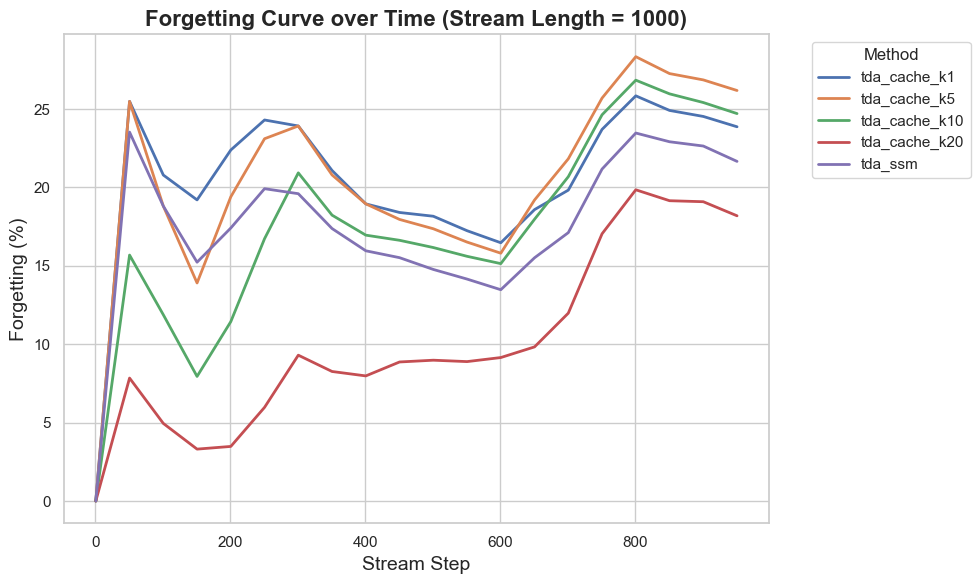

In [21]:
# Plot forgetting curve for the longest stream length available
max_stream = curves_df['stream_length'].max()
subset_curves = curves_df[curves_df['stream_length'] == max_stream]

plt.figure(figsize=(10, 6))
sns.lineplot(data=subset_curves, x='step', y='forgetting', hue='method', linewidth=2)
plt.title(f'Forgetting Curve over Time (Stream Length = {max_stream})', fontsize=16, fontweight='bold')
plt.xlabel('Stream Step', fontsize=14)
plt.ylabel('Forgetting (%)', fontsize=14)
plt.legend(title='Method', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

/var/folders/xx/t73hkxhx7xj95d9rl4spgtb00000gn/T/ipykernel_43901/3518068921.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=max_stream_summary, x='method', y='adapter_memory_mb', ax=axes[0], palette='viridis')
/var/folders/xx/t73hkxhx7xj95d9rl4spgtb00000gn/T/ipykernel_43901/3518068921.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=max_stream_summary, x='method', y='avg_step_time_ms', ax=axes[1], palette='magma')


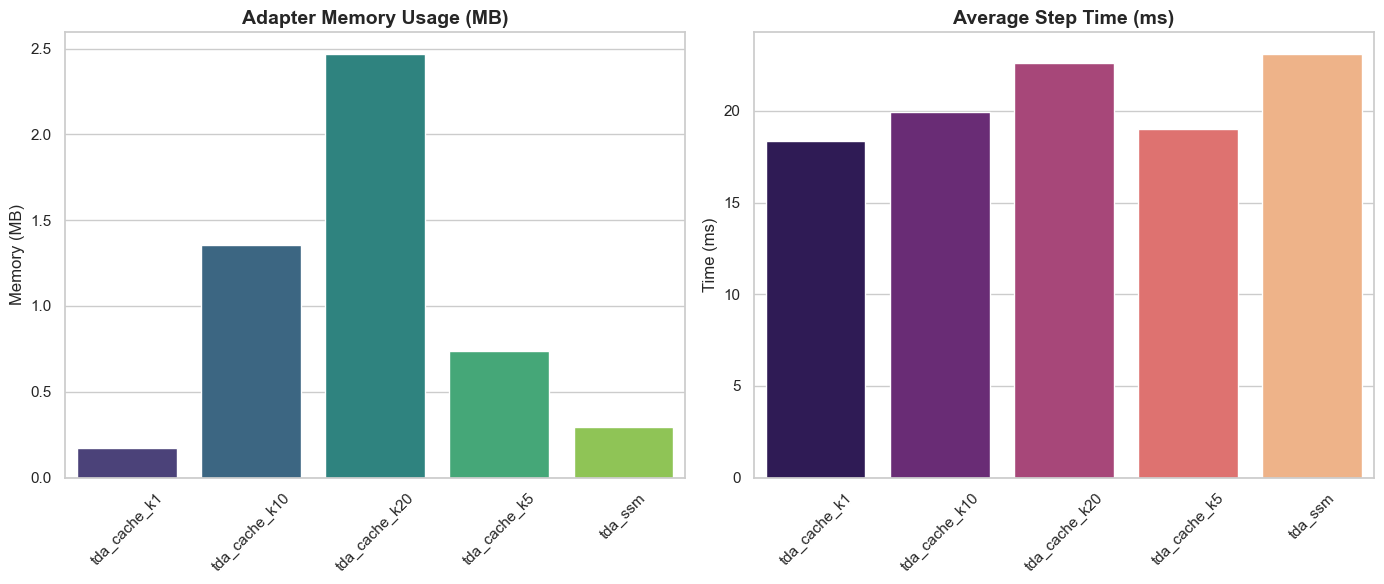

In [22]:
# Filter for the maximum stream length to compare efficiency
max_stream_summary = summary_df[summary_df['stream_length'] == summary_df['stream_length'].max()].copy()
max_stream_summary.sort_values('method', inplace=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Memory Plot
sns.barplot(data=max_stream_summary, x='method', y='adapter_memory_mb', ax=axes[0], palette='viridis')
axes[0].set_title('Adapter Memory Usage (MB)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Memory (MB)', fontsize=12)
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=45)

# Runtime Plot
sns.barplot(data=max_stream_summary, x='method', y='avg_step_time_ms', ax=axes[1], palette='magma')
axes[1].set_title('Average Step Time (ms)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Time (ms)', fontsize=12)
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()